Now let's determine the matrix factorization benchmark for our specific dataset and splits. We'd like to use this is addition to the literature figure since there is no telling if that dataset maps well to our dataset. This will give us a more "apples to apples" assessment of the NLP model performance.

A content boosted MF and SVD++ were attempted but there was virtually no improvement, likely because of how "warm" the dataset is.

In [12]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# Imports
import json
import numpy as np
from pathlib import Path
from typing import Tuple, Dict
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, metrics
import matplotlib.pyplot as plt
from collections import Counter, defaultdict, deque
import random

In [14]:
# --- loader: now also exposes user_id and business_id arrays in each split ---

def load_split_file(
    path: str,
    variant: str = 'A'  # 'A' for business_pool_with_category, 'B' for separate business_pool + business_category_embedding
):
    """
    Returns: user_embs, business_embs, stars, meta dict with review_id, user_id, business_id
    """
    user_list, business_list, star_list = [], [], []
    review_ids, user_ids, business_ids = [], [], []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            r = json.loads(line)
            user_pool = np.array(r['user_pool'], dtype=float)
            if variant == 'A':
                business_feat = np.array(r['business_pool_with_category'], dtype=float)
            elif variant == 'B':
                business_pool = np.array(r.get('business_pool', []), dtype=float)
                cat_emb = np.array(r.get('business_category_embedding', []), dtype=float)
                if business_pool.size and cat_emb.size:
                    business_feat = np.concatenate([business_pool, cat_emb])
                elif business_pool.size:
                    business_feat = business_pool
                elif cat_emb.size:
                    business_feat = cat_emb
                else:
                    raise ValueError(f"Missing business features in {r.get('review_id')}")
            else:
                raise ValueError("variant must be 'A' or 'B'")

            stars = float(r['stars'])
            user_list.append(user_pool)
            business_list.append(business_feat)
            star_list.append(stars)
            review_ids.append(r.get('review_id'))
            user_ids.append(r.get('user_id'))
            business_ids.append(r.get('business_id'))

    user_embs = np.vstack(user_list) if user_list else np.zeros((0, 0))
    business_embs = np.vstack(business_list) if business_list else np.zeros((0, 0))
    stars = np.array(star_list, dtype=float) if star_list else np.zeros((0,))
    meta = {
        'review_id': np.array(review_ids, dtype=object),
        'user_id':   np.array(user_ids, dtype=object),
        'business_id': np.array(business_ids, dtype=object),
    }
    return user_embs, business_embs, stars, meta


def load_all_splits(
    train_path: str,
    val_path: str,
    test_path: str,
    variant: str = 'A'
):
    splits = {}
    for name, path in [('train', train_path), ('val', val_path), ('test', test_path)]:
        user_embs, business_embs, stars, meta = load_split_file(path, variant=variant)
        splits[name] = {
            'user': user_embs,
            'business': business_embs,
            'stars': stars,
            # expose string IDs directly in split (in addition to meta) as requested
            'user_id': meta['user_id'],
            'business_id': meta['business_id'],
            'meta': meta
        }
    return splits

In [4]:
def mf_sparsity_overlap_report(
    splits,
    k_list=(1, 2, 5, 10),
    top_frac=0.2,
    sample_user_pairs=20000,
    seed=42,
):
    """
    Compute sparsity & overlap metrics for MF viability on the TRAIN split.

    Returns a dict with:
      - basic: n_users, n_items, n_interactions, density, sparsity
      - user_degree / item_degree: {mean, median, min, max, std}
      - coverage: top-{top_frac} users/items coverage of interactions, gini for degrees
      - k_thresholds: pct users/items with >= k for k in k_list
      - components: largest connected component (LCC) coverage by nodes & interactions
      - overlap_samples: sampled user-user co-rating stats (intersection size & Jaccard)
    """
    rng = np.random.default_rng(seed)

    train = splits["train"]
    uids = train["user_id"]
    iids = train["business_id"]

    # --- index users/items ---
    unique_users, user_idx = np.unique(uids, return_inverse=True)
    unique_items, item_idx = np.unique(iids, return_inverse=True)

    U = unique_users.size
    I = unique_items.size
    N = len(uids)

    # --- degrees & adjacency sets ---
    user_deg = np.zeros(U, dtype=np.int32)
    item_deg = np.zeros(I, dtype=np.int32)
    user2items = [set() for _ in range(U)]
    item2users = [set() for _ in range(I)]

    for u, i in zip(user_idx, item_idx):
        user_deg[u] += 1
        item_deg[i] += 1
        user2items[u].add(i)
        item2users[i].add(u)

    density = N / (U * I) if U > 0 and I > 0 else 0.0
    sparsity = 1.0 - density

    def stats(arr):
        if len(arr) == 0:
            return {"mean": 0, "median": 0, "min": 0, "max": 0, "std": 0}
        return {
            "mean": float(np.mean(arr)),
            "median": float(np.median(arr)),
            "min": int(np.min(arr)),
            "max": int(np.max(arr)),
            "std": float(np.std(arr)),
        }

    def gini_coeff(x):
        x = np.asarray(x, dtype=np.float64)
        if np.all(x == 0): return 0.0
        x = np.sort(x)
        n = x.size
        cumx = np.cumsum(x)
        # Gini = 1 + (1/n) - 2 * sum_i (cumx_i) / (n * sum_x)
        return float(1 + 1/n - 2 * np.sum(cumx) / (n * np.sum(x)))

    def top_frac_coverage(deg_vec, frac):
        n = len(deg_vec)
        k = max(1, int(np.floor(frac * n)))
        top_sum = np.sum(np.sort(deg_vec)[-k:])
        return float(top_sum / np.sum(deg_vec)) if np.sum(deg_vec) > 0 else 0.0

    # --- largest connected component over bipartite graph ---
    # Build undirected adjacency across combined node space: [0..U-1] users, [U..U+I-1] items
    adj = [set() for _ in range(U + I)]
    for u in range(U):
        for i in user2items[u]:
            ui = U + i
            adj[u].add(ui)
            adj[ui].add(u)

    visited = np.zeros(U + I, dtype=bool)
    comp_sizes_nodes = []
    comp_sizes_edges = []

    # edges count = interactions inside a component; we can count by summing degrees/2
    for start in range(U + I):
        if not visited[start] and adj[start]:
            q = deque([start])
            visited[start] = True
            nodes = []
            edge_deg_sum = 0
            while q:
                v = q.popleft()
                nodes.append(v)
                edge_deg_sum += len(adj[v])
                for w in adj[v]:
                    if not visited[w]:
                        visited[w] = True
                        q.append(w)
            comp_sizes_nodes.append(len(nodes))
            comp_sizes_edges.append(edge_deg_sum // 2)  # undirected

    if comp_sizes_nodes:
        lcc_nodes = max(comp_sizes_nodes)
        lcc_edges = max(comp_sizes_edges)
        node_coverage = lcc_nodes / (U + I)
        edge_coverage = lcc_edges / N if N > 0 else 0.0
    else:
        node_coverage = 0.0
        edge_coverage = 0.0

    # --- k-threshold coverage ---
    k_user = {int(k): float(np.mean(user_deg >= k)) for k in k_list}
    k_item = {int(k): float(np.mean(item_deg >= k)) for k in k_list}

    # --- sampled user-user overlap (intersection & Jaccard over items) ---
    # If few users, do all pairs; else sample.
    all_pairs = U * (U - 1) // 2
    to_sample = min(all_pairs, sample_user_pairs)
    inter_sizes = []
    jaccs = []
    if U >= 2 and to_sample > 0:
        if to_sample == all_pairs and U <= 4000:
            # enumerate all pairs
            for a in range(U):
                Ia = user2items[a]
                for b in range(a + 1, U):
                    Ib = user2items[b]
                    inter = len(Ia & Ib)
                    union = len(Ia | Ib)
                    inter_sizes.append(inter)
                    jaccs.append(inter / union if union > 0 else 0.0)
        else:
            # random sampling
            for _ in range(to_sample):
                a, b = rng.choice(U, size=2, replace=False)
                Ia, Ib = user2items[a], user2items[b]
                inter = len(Ia & Ib)
                union = len(Ia | Ib)
                inter_sizes.append(inter)
                jaccs.append(inter / union if union > 0 else 0.0)

    def qstats(x):
        if not x:
            return {"mean": 0.0, "median": 0.0, "p90": 0.0, "max": 0.0}
        x = np.asarray(x, dtype=float)
        return {
            "mean": float(x.mean()),
            "median": float(np.median(x)),
            "p90": float(np.quantile(x, 0.90)),
            "max": float(x.max()),
        }

    report = {
        "basic": {
            "n_users": int(U),
            "n_items": int(I),
            "n_interactions": int(N),
            "density": float(density),
            "sparsity": float(sparsity),
        },
        "user_degree": stats(user_deg),
        "item_degree": stats(item_deg),
        "coverage": {
            f"top_{int(top_frac*100)}pct_users_interactions": top_frac_coverage(user_deg, top_frac),
            f"top_{int(top_frac*100)}pct_items_interactions": top_frac_coverage(item_deg, top_frac),
            "gini_user_degree": gini_coeff(user_deg),
            "gini_item_degree": gini_coeff(item_deg),
        },
        "k_thresholds": {
            "users_ge_k": k_user,
            "items_ge_k": k_item,
        },
        "components": {
            "lcc_node_coverage": float(node_coverage),
            "lcc_interaction_coverage": float(edge_coverage),
            "n_components_with_edges": int(len(comp_sizes_nodes)),
        },
        "overlap_samples": {
            "n_user_pairs_sampled": int(len(inter_sizes)),
            "intersection_stats": qstats(inter_sizes),
            "jaccard_stats": qstats(jaccs),
        },
    }
    return report


In [7]:
def train_mf(
    splits,
    k=64,                 # latent factors
    epochs=50,
    lr=0.01,              # learning rate
    reg=0.01,             # L2 regularization (applied to P,Q,bu,bi)
    batch_size=4096,
    clip_ratings=(1.0, 5.0),  # clip preds for metric reporting; None = no clip
    seed=42,
    verbose=1,
):
    """
    Matrix Factorization with user/item biases trained via mini-batch SGD.

    Expects `splits` like:
      splits['train']['user_id']  -> np.array of strings
      splits['train']['business_id']
      splits['train']['stars']    -> float ratings
    Same keys for 'val' and 'test'.

    Returns:
      params: dict with P,Q,bu,bi,mu,user_index,item_index
      history: dict with train/val MSE & RMSE per epoch
    """
    rng = np.random.default_rng(seed)

    # ----- Build ID -> index from TRAIN only -----
    train_users = splits['train']['user_id']
    train_items = splits['train']['business_id']
    train_r     = splits['train']['stars'].astype(float)

    user_ids = np.unique(train_users)
    item_ids = np.unique(train_items)
    user_index = {u:i for i,u in enumerate(user_ids)}
    item_index = {it:i for i,it in enumerate(item_ids)}

    n_users = len(user_ids)
    n_items = len(item_ids)
    if verbose:
        print(f"Training MF on {len(train_r)} interactions, {n_users} users, {n_items} items")

    # Map TRAIN triples to indices
    train_u_idx = np.array([user_index[u] for u in train_users], dtype=np.int32)
    train_i_idx = np.array([item_index[i] for i in train_items], dtype=np.int32)

    # ----- Initialize parameters -----
    mu = float(train_r.mean())
    P  = 0.01 * rng.standard_normal((n_users, k))
    Q  = 0.01 * rng.standard_normal((n_items, k))
    bu = np.zeros(n_users, dtype=np.float64)
    bi = np.zeros(n_items, dtype=np.float64)

    # ----- Helpers -----
    def predict(u_idx, i_idx, clip_for_metric=False):
        """Vectorized prediction for arrays of indices."""
        r = mu + bu[u_idx] + bi[i_idx] + np.sum(P[u_idx] * Q[i_idx], axis=1)
        if clip_for_metric and clip_ratings is not None:
            lo, hi = clip_ratings
            r = np.clip(r, lo, hi)
        return r

    def metrics_for_split(split_name):
        """Return (mse, rmse, n_used) for a split, skipping unseen IDs if any."""
        u_ids = splits[split_name]['user_id']
        i_ids = splits[split_name]['business_id']
        y     = splits[split_name]['stars'].astype(float)

        # mask examples that exist in the train-built index
        mask = np.array([(u in user_index) and (i in item_index) for u,i in zip(u_ids, i_ids)])
        if not np.any(mask):
            return np.nan, np.nan, 0

        u_idx = np.array([user_index[u] for u in u_ids[mask]], dtype=np.int32)
        i_idx = np.array([item_index[i] for i in i_ids[mask]], dtype=np.int32)
        y_sub = y[mask]

        y_hat = predict(u_idx, i_idx, clip_for_metric=True)
        mse = np.mean((y_hat - y_sub)**2)
        rmse = float(np.sqrt(mse))
        return float(mse), rmse, int(mask.sum())

    # Precompute index order for batching
    n_train = len(train_r)
    order = np.arange(n_train)

    history = {
        'train_loss': [], 'train_rmse': [],
        'val_loss':   [], 'val_rmse':   []
    }

    # ----- Training loop -----
    for epoch in range(1, epochs+1):
        rng.shuffle(order)

        for start in range(0, n_train, batch_size):
            batch = order[start:start+batch_size]
            u = train_u_idx[batch]
            i = train_i_idx[batch]
            r = train_r[batch]

            # predictions & errors (no clipping for training updates)
            r_hat = mu + bu[u] + bi[i] + np.sum(P[u] * Q[i], axis=1)
            e = r - r_hat

            # SGD updates (loop per sample to avoid advanced-indexing copy issues)
            for n in range(len(batch)):
                ui = u[n]; ii = i[n]; err = e[n]

                # cache current factors
                Pu = P[ui].copy()
                Qi = Q[ii].copy()

                # biases
                bu[ui] += lr * (err - reg * bu[ui])
                bi[ii] += lr * (err - reg * bi[ii])

                # factors
                P[ui]  += lr * (err * Qi - reg * Pu)
                Q[ii]  += lr * (err * Pu - reg * Qi)

        # end epoch: metrics
        # Train metrics over full train (report clipped RMSE; loss = MSE)
        train_pred = predict(train_u_idx, train_i_idx, clip_for_metric=True)
        train_mse  = float(np.mean((train_pred - train_r)**2))
        train_rmse = float(np.sqrt(train_mse))

        val_mse, val_rmse, n_val = metrics_for_split('val')

        history['train_loss'].append(train_mse)
        history['train_rmse'].append(train_rmse)
        history['val_loss'].append(val_mse)
        history['val_rmse'].append(val_rmse)

        if verbose:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"train RMSE {train_rmse:.4f} (MSE {train_mse:.4f})  |  "
                  f"val RMSE {val_rmse:.4f} (MSE {val_mse:.4f})  |  "
                  f"N_val {n_val}")

    # ----- Final test RMSE -----
    test_mse, test_rmse, n_test = metrics_for_split('test')
    print(f"\nTest RMSE: {test_rmse:.4f} (N={n_test})")

    params = {
        'P': P, 'Q': Q, 'bu': bu, 'bi': bi, 'mu': mu,
        'user_index': user_index, 'item_index': item_index, 'k': k
    }
    return params, history

In [8]:
def plot_mf_history(history, last_n=50):
    h = history
    epochs = np.arange(1, len(h['train_loss']) + 1)

    # --- MSE ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, h['train_loss'], label='Train MSE')
    if len(h['val_loss']) == len(h['train_loss']):
        plt.plot(epochs, h['val_loss'], label='Val MSE')
        best_mse_idx = int(np.nanargmin(h['val_loss']))
        plt.axvline(best_mse_idx + 1, ls='--', alpha=0.3, label=f'Best Val MSE @ {best_mse_idx+1}')
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('MSE over Epochs')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Zoom MSE
    start = max(0, len(epochs) - last_n)
    zoom_epochs = epochs[start:]
    plt.figure(figsize=(6,4))
    plt.plot(zoom_epochs, h['train_loss'][start:], label='Train MSE')
    if len(h['val_loss']) == len(h['train_loss']):
        plt.plot(zoom_epochs, h['val_loss'][start:], label='Val MSE')
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title(f'MSE over Last {last_n} Epochs')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # --- RMSE ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, h['train_rmse'], label='Train RMSE')
    if len(h['val_rmse']) == len(h['train_rmse']):
        plt.plot(epochs, h['val_rmse'], label='Val RMSE')
        best_rmse_idx = int(np.nanargmin(h['val_rmse']))
        plt.axvline(best_rmse_idx + 1, ls='--', alpha=0.3, label=f'Best Val RMSE @ {best_rmse_idx+1}')
    plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.title('RMSE over Epochs')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Zoom RMSE
    plt.figure(figsize=(6,4))
    plt.plot(zoom_epochs, h['train_rmse'][start:], label='Train RMSE')
    if len(h['val_rmse']) == len(h['train_rmse']):
        plt.plot(zoom_epochs, h['val_rmse'][start:], label='Val RMSE')
    plt.xlabel('Epoch'); plt.ylabel('RMSE'); plt.title(f'RMSE over Last {last_n} Epochs')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Print best epochs
    best_val_mse_epoch = int(np.nanargmin(h['val_loss'])) + 1 if len(h['val_loss']) else None
    best_val_rmse_epoch = int(np.nanargmin(h['val_rmse'])) + 1 if len(h['val_rmse']) else None
    if best_val_mse_epoch:
        print(f"Best Val MSE: {h['val_loss'][best_val_mse_epoch-1]:.4f} @ epoch {best_val_mse_epoch}")
    if best_val_rmse_epoch:
        print(f"Best Val RMSE: {h['val_rmse'][best_val_rmse_epoch-1]:.4f} @ epoch {best_val_rmse_epoch}")

In [15]:
# Set file paths
path_train_B= "/content/drive/MyDrive/Colab_Folder/266_Project/Features/SBERT_12Layer/_train_B.json"
path_val_B = "/content/drive/MyDrive/Colab_Folder/266_Project/Features/SBERT_12Layer/_val_B.json"
path_test_B = "/content/drive/MyDrive/Colab_Folder/266_Project/Features/SBERT_12Layer/_test_B.json"

# Extract different split files (B is concatenated tags)
splits_B = load_all_splits(train_path=path_train_B, val_path=path_val_B, test_path=path_test_B, variant='B')

In [6]:
# Calculate MF data stats
stats = mf_sparsity_overlap_report(splits_B, k_list=(1,3,5,10), top_frac=0.2, sample_user_pairs=50000)
import pprint; pprint.pprint(stats)

{'basic': {'density': 0.06856915014809752,
           'n_interactions': 54171,
           'n_items': 1188,
           'n_users': 665,
           'sparsity': 0.9314308498519025},
 'components': {'lcc_interaction_coverage': 1.0,
                'lcc_node_coverage': 1.0,
                'n_components_with_edges': 1},
 'coverage': {'gini_item_degree': 0.32303275877789916,
              'gini_user_degree': 0.22794983804418845,
              'top_20pct_items_interactions': 0.4178434955972753,
              'top_20pct_users_interactions': 0.3541193627586716},
 'item_degree': {'max': 237,
                 'mean': 45.59848484848485,
                 'median': 34.0,
                 'min': 16,
                 'std': 30.763427131624447},
 'k_thresholds': {'items_ge_k': {1: 1.0, 3: 1.0, 5: 1.0, 10: 1.0},
                  'users_ge_k': {1: 1.0, 3: 1.0, 5: 1.0, 10: 1.0}},
 'overlap_samples': {'intersection_stats': {'max': 139.0,
                                            'mean': 8.0212,
         

Matrix is relatively dense and well connected so biased MF as defined above should work relatively well for this dataset.

Training MF on 54171 interactions, 665 users, 1188 items
Epoch   1/50 | train RMSE 0.9039 (MSE 0.8170)  |  val RMSE 0.9082 (MSE 0.8249)  |  N_val 6520
Epoch   2/50 | train RMSE 0.8743 (MSE 0.7644)  |  val RMSE 0.8833 (MSE 0.7802)  |  N_val 6520
Epoch   3/50 | train RMSE 0.8578 (MSE 0.7358)  |  val RMSE 0.8700 (MSE 0.7570)  |  N_val 6520
Epoch   4/50 | train RMSE 0.8476 (MSE 0.7185)  |  val RMSE 0.8620 (MSE 0.7431)  |  N_val 6520
Epoch   5/50 | train RMSE 0.8410 (MSE 0.7073)  |  val RMSE 0.8571 (MSE 0.7347)  |  N_val 6520
Epoch   6/50 | train RMSE 0.8365 (MSE 0.6996)  |  val RMSE 0.8539 (MSE 0.7291)  |  N_val 6520
Epoch   7/50 | train RMSE 0.8332 (MSE 0.6942)  |  val RMSE 0.8521 (MSE 0.7260)  |  N_val 6520
Epoch   8/50 | train RMSE 0.8308 (MSE 0.6902)  |  val RMSE 0.8507 (MSE 0.7237)  |  N_val 6520
Epoch   9/50 | train RMSE 0.8290 (MSE 0.6872)  |  val RMSE 0.8497 (MSE 0.7220)  |  N_val 6520
Epoch  10/50 | train RMSE 0.8276 (MSE 0.6848)  |  val RMSE 0.8489 (MSE 0.7207)  |  N_val 6520
Epo

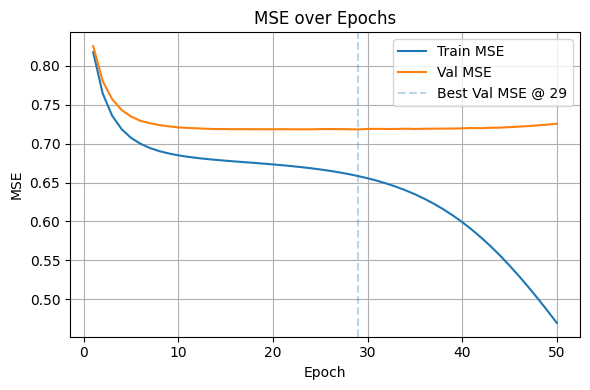

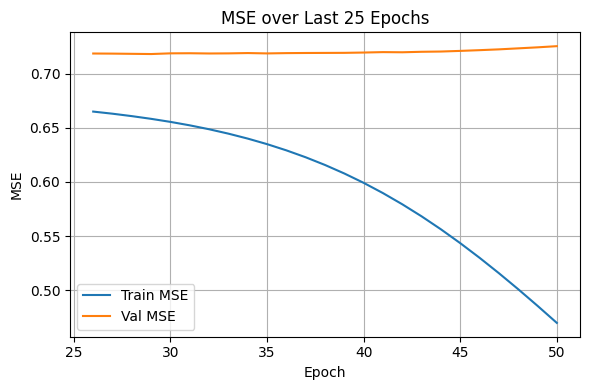

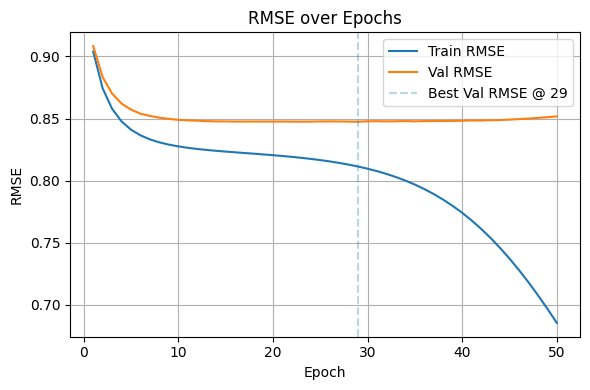

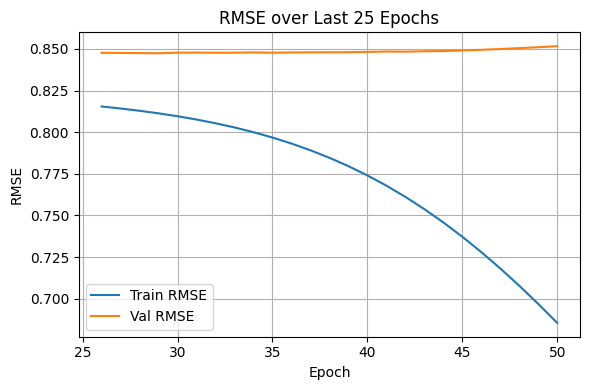

Best Val MSE: 0.7181 @ epoch 29
Best Val RMSE: 0.8474 @ epoch 29


In [11]:
params, history = train_mf(
    splits_B,
    k=128,
    epochs=50,
    lr=0.005,
    reg=0,
    batch_size=4096,
    clip_ratings=(1.0, 5.0),
    seed=42,
    verbose=1
)

plot_mf_history(history, last_n=25)

Rerun at best epoch to get test set metric

Training MF on 54171 interactions, 665 users, 1188 items
Epoch   1/29 | train RMSE 0.9039 (MSE 0.8170)  |  val RMSE 0.9082 (MSE 0.8249)  |  N_val 6520
Epoch   2/29 | train RMSE 0.8743 (MSE 0.7644)  |  val RMSE 0.8833 (MSE 0.7802)  |  N_val 6520
Epoch   3/29 | train RMSE 0.8578 (MSE 0.7358)  |  val RMSE 0.8700 (MSE 0.7570)  |  N_val 6520
Epoch   4/29 | train RMSE 0.8476 (MSE 0.7185)  |  val RMSE 0.8620 (MSE 0.7431)  |  N_val 6520
Epoch   5/29 | train RMSE 0.8410 (MSE 0.7073)  |  val RMSE 0.8571 (MSE 0.7347)  |  N_val 6520
Epoch   6/29 | train RMSE 0.8365 (MSE 0.6996)  |  val RMSE 0.8539 (MSE 0.7291)  |  N_val 6520
Epoch   7/29 | train RMSE 0.8332 (MSE 0.6942)  |  val RMSE 0.8521 (MSE 0.7260)  |  N_val 6520
Epoch   8/29 | train RMSE 0.8308 (MSE 0.6902)  |  val RMSE 0.8507 (MSE 0.7237)  |  N_val 6520
Epoch   9/29 | train RMSE 0.8290 (MSE 0.6872)  |  val RMSE 0.8497 (MSE 0.7220)  |  N_val 6520
Epoch  10/29 | train RMSE 0.8276 (MSE 0.6848)  |  val RMSE 0.8489 (MSE 0.7207)  |  N_val 6520
Epo

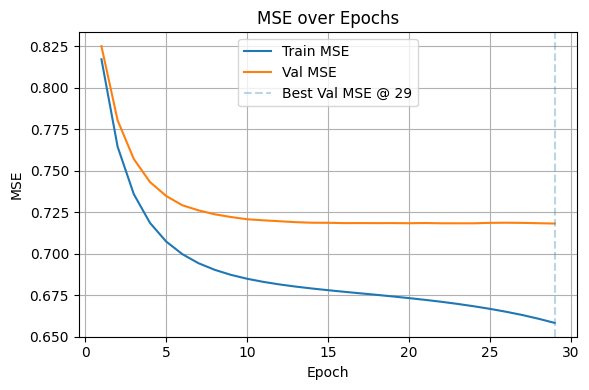

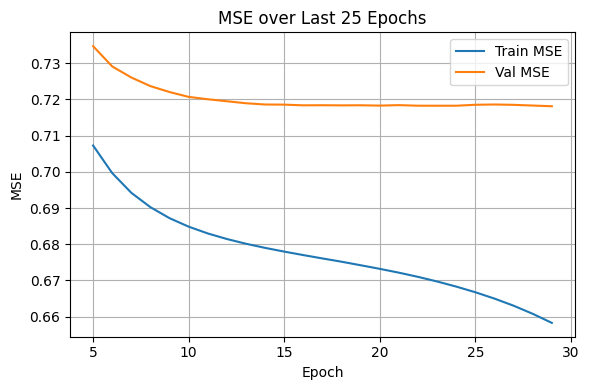

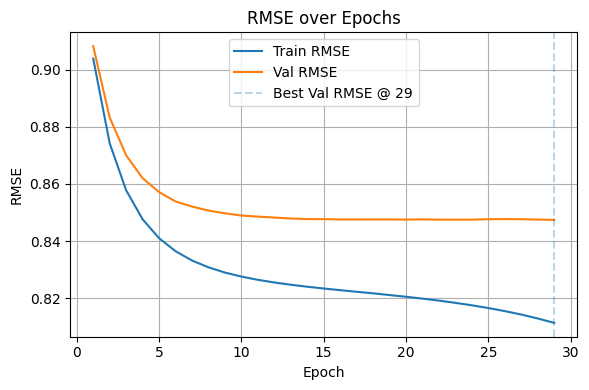

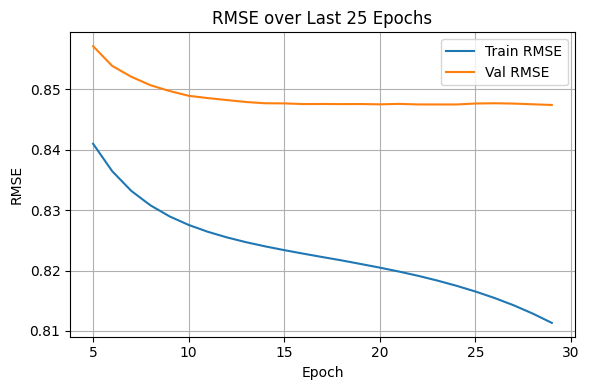

Best Val MSE: 0.7181 @ epoch 29
Best Val RMSE: 0.8474 @ epoch 29


In [25]:
params, history = train_mf(
    splits_B,
    k=128,
    epochs=29,
    lr=0.005,
    reg=0,
    batch_size=4096,
    clip_ratings=(1.0, 5.0),
    seed=42,
    verbose=1
)

plot_mf_history(history, last_n=25)